# Notebook : functions

---

## Histogram Task : generate random dataset

In [2]:
import random
import string
import matplotlib.pyplot as plt
from math import comb

In [3]:
def generate_random_pos(T, L):
    """
    Génère uniformément une composition aléatoire de T
    dont la longueur (nombre de parts) est au plus L.
    """
    if T <= 0:
        raise ValueError("T doit être un entier positif.")
    if L <= 0:
        raise ValueError("L doit être un entier positif.")

    # 1) Choisir uniformément une longueur k dans [1, min(T, L)]
    k = random.randint(1, min(T, L))

    # 2) Choisir k−1 positions de coupures dans les T−1 positions possibles
    cuts = sorted(random.sample(range(1, T), k - 1))

    # 3) Construire les segments entre les coupures
    parts = []
    prev = 0
    for c in cuts:
        parts.append(c - prev)
        prev = c

    # Dernier segment
    parts.append(T - prev)

    return parts

In [4]:
def generate_histogram_task(T, L):
    """
    À partir d'une liste d'entiers positifs (composition),
    renvoie :
        - seq : liste mélangée de lettres (taille T)
        - count_vector : liste (taille T) avec le nombre d'occurrences
                         de la lettre présente à chaque position.
    """
    alphabet = string.ascii_uppercase
    counts = generate_random_pos(T, L)
    
    if len(counts) > len(alphabet):
        raise ValueError("Alphabet insuffisant.")
    
    seq = []
    letter_count_map = {} 
    
    for i, k in enumerate(counts):
        letter = alphabet[i]
        letter_count_map[letter] = k
        seq.extend([letter] * k)
    
    random.shuffle(seq)
    count_vector = [letter_count_map[letter] for letter in seq]
    
    return seq, count_vector

def generate_histogram_task(T, L):
    """
    Génère une séquence d'entiers (taille T) à partir d'une composition aléatoire,
    et un vecteur de comptage correspondant au nombre d'occurrences de chaque entier.

    Renvoie :
        - seq : liste mélangée d'entiers (taille T)
        - count_vector : liste (taille T) avec le nombre d'occurrences
                         de l'entier présent à chaque position
    """
    counts = generate_random_pos(T, L)
    
    if len(counts) > T:
        raise ValueError("Nombre de valeurs uniques trop élevé par rapport à T")
    
    seq = []
    value_count_map = {}
    
    for i, k in enumerate(counts):
        value = i 
        value_count_map[value] = k
        seq.extend([value] * k)
    
    random.shuffle(seq)
    count_vector = [value_count_map[val] for val in seq]
    
    return seq, count_vector

In [5]:
T = 5
L = 5
seq, count_vec = generate_histogram_task(T, L)
print("Seq =", seq)
print("Count vector =", count_vec)

Seq = [0, 0, 0, 0, 0]
Count vector = [5, 5, 5, 5, 5]


---

## accuracy

In [6]:
def accuracy(pred, true):
    """
    Calcule la précision (accuracy) entre deux séquences de labels.
    
    Args:
        pred: liste, numpy array ou torch tensor des prédictions
        true: liste, numpy array ou torch tensor des labels réels
    
    Returns:
        float: fraction de prédictions correctes (entre 0 et 1)
    """
    # Conversion en listes si nécessaire
    if hasattr(pred, "tolist"):
        pred = pred.tolist()
    if hasattr(true, "tolist"):
        true = true.tolist()
    
    if len(pred) != len(true):
        raise ValueError(f"Les listes doivent avoir la même longueur "
                         f"(pred={len(pred)}, true={len(true)})")
    
    if len(true) == 0:
        return 0.0  
    
    correct = sum(p == t for p, t in zip(pred, true))
    return correct / len(true)

In [7]:
L, T = 15, 30
seq1, count_vec1 = generate_histogram_task(T, L)
seq2, count_vec2 = generate_histogram_task(T, L)
acc = accuracy(count_vec1, count_vec2)
print("Seq1 =", seq1)
print("Count vector 1 =", count_vec1)
print("Seq2 =", seq2)
print("Count vector 2 =", count_vec2)
print("Accuracy =", acc)

Seq1 = [0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 0]
Count vector 1 = [22, 22, 22, 22, 8, 22, 22, 22, 22, 8, 8, 22, 22, 8, 22, 22, 22, 22, 22, 22, 22, 22, 8, 22, 8, 22, 22, 8, 8, 22]
Seq2 = [1, 0, 1, 2, 1, 1, 1, 2, 2, 1, 1, 1, 2, 2, 1, 2, 0, 0, 1, 0, 2, 2, 1, 2, 2, 0, 2, 1, 2, 1]
Count vector 2 = [13, 5, 13, 12, 13, 13, 13, 12, 12, 13, 13, 13, 12, 12, 13, 12, 5, 5, 13, 5, 12, 12, 13, 12, 12, 5, 12, 13, 12, 13]
Accuracy = 0.0


---

## Porbability to construct (L,T)

L = 5 : minimum T = 10
L = 10 : minimum T = 19
L = 15 : minimum T = 27
L = 20 : minimum T = 36
L = 25 : minimum T = 45
L = 30 : minimum T = 53


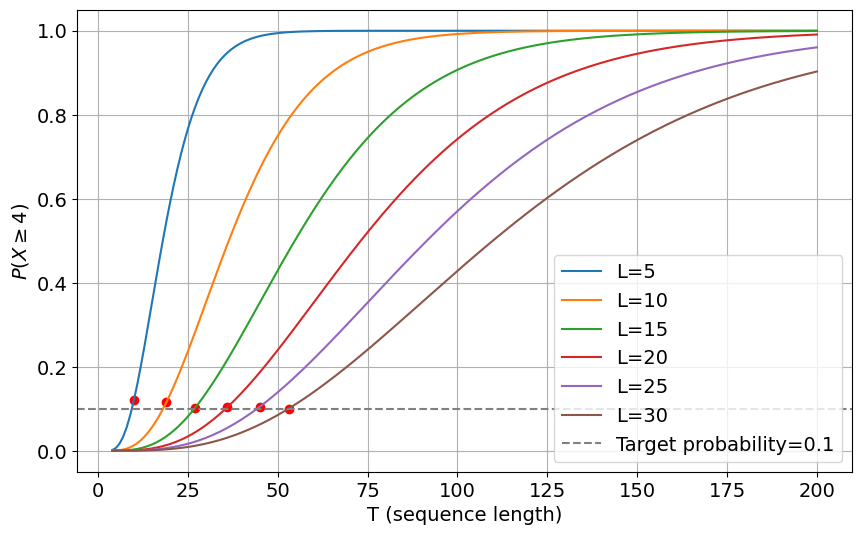

In [9]:
def prob_at_least_k(T, L, k):
    """Probability that a letter appears at least k times in T draws from an alphabet of size L"""
    p = 1 / L
    prob = sum(comb(T, i) * (p ** i) * ((1 - p) ** (T - i)) for i in range(k))
    return 1 - prob

def find_min_T(L, k, target_prob=0.1, max_T=1000):
    """Find the smallest T such that P(X >= k) > target_prob"""
    for T in range(k, max_T+1):
        if prob_at_least_k(T, L, k) > target_prob:
            return T
    return None  # if not found

# Parameters
alphabet_sizes = [5, 10, 15, 20,25, 30]  # different alphabet sizes L
k = 4
target_prob = 0.1
max_T = 200

# Compute T_min for each L
T_min_values = {}
for L in alphabet_sizes:
    T_min = find_min_T(L, k, target_prob, max_T)
    T_min_values[L] = T_min
    print(f"L = {L} : minimum T = {T_min}")

# Plot probabilities to visualize
plt.rcParams.update({'font.size': 14}) 
plt.figure(figsize=(10,6))
for L in alphabet_sizes:
    T_range = range(k, max_T+1)
    probs = [prob_at_least_k(T, L, k) for T in T_range]
    plt.plot(T_range, probs, label=f"L={L}")
    if T_min_values[L]:
        plt.scatter(T_min_values[L], prob_at_least_k(T_min_values[L], L, k), color='red')

plt.axhline(y=target_prob, color='gray', linestyle='--', label=f"Target probability={target_prob}")
plt.xlabel("T (sequence length)")
plt.ylabel(fr"$P(X \geq {k})$")
#plt.title(f"Probability of having at least {k} occurrences of a letter")
plt.legend()
plt.grid(True)
plt.show()